# Gulf Stream Extension Region (GSER) in SWOT

This notebook's purpose is to first visualize the GSER from selected SWOT passes and to get a first sense of submesoscale dynamics in the area.

In [3]:
import numpy as np
import xarray as xr
from pathlib import Path
import glob

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from swot_analysis.swot_alongtrack_spectra import load_swot_l2, compute_pass_spectra
from swot_analysis import plotting
from swot_analysis.swot_alongtrack_slope import compute_pass_slope, compute_swath_slope_spectrum

In [4]:
data_dir = '/Users/zoecas/Documents/data/'
data_subdir = "SWOT_L2_LR_SSH_D_D-20260702_095005"
#file = "SWOT_L2_LR_SSH_Expert_045_216_20260131T225821_20260131T234949_PID0_01.nc"

#Reading several swaths files
if True:
    data_dir = Path(data_dir+data_subdir)
    files = list(sorted(data_dir.glob('SWOT_L2_LR_SSH_*.nc')))
    print(f'Found {len(list(files))} files')


#data = load_swot_l2(data_dir+file, ssh_var="ssha_karin_2")


Found 71 files


In [6]:
swaths = {str(i) : load_swot_l2(f, ssh_var="ssha_karin_2") for i,f in enumerate(files)}

In [11]:
swaths['0']

{'ssha': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(9866, 69)),
 'latitude': array([[ 78.272006,  78.254093,  78.236179, ...,  77.089667,  77.071752,
          77.053837],
        [ 78.272051,  78.254138,  78.236224, ...,  77.089708,  77.071793,
          77.053878],
        [ 78.272068,  78.254155,  78.236241, ...,  77.089724,  77.071808,
          77.053893],
        ...,
        [-77.053767, -77.071682, -77.089597, ..., -78.236115, -78.254028,
         -78.271942],
        [-77.053747, -77.071662, -77.089577, ..., -78.236092, -78.254006,
         -78.27192 ],
        [-77.053701, -77.071617, -77.089532, ..., -78.236043, -78.253956,
         -78.27187 ]], shape=(9866, 69)),
 'longitude': array([[230.232992, 230.233281, 230.233568, ..., 230.2

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_14922/613003795.py:9: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(swaths[s]['longitude'],swaths[s]['latitude'],swaths[s]['ssha'])


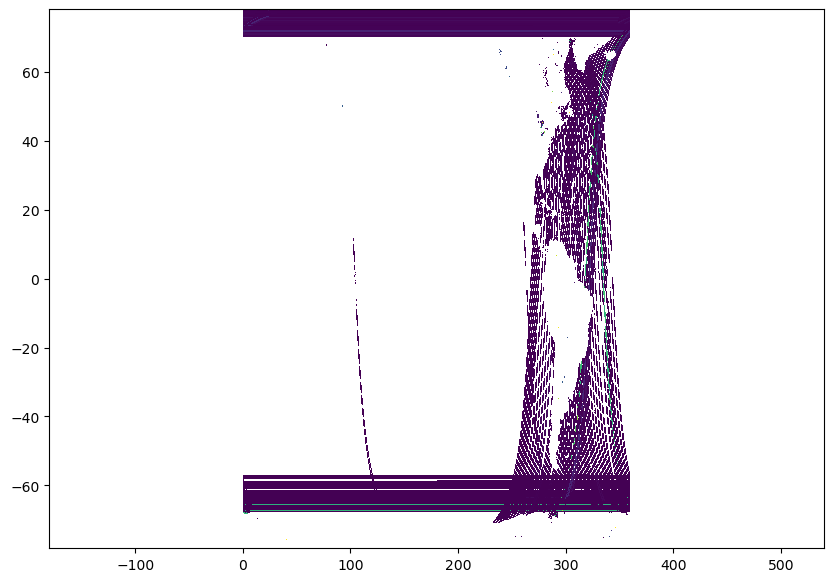

In [12]:
# Whole dataset
title = 'SSHA [m]'
fig,ax = plt.subplots(figsize=(10,7))
#dat = data["ssha"]
#lon = data["longitude"]
#lat = data["latitude"]
vmin, vmax = -0.5,0.5
for s in swaths.keys():
    ax.pcolormesh(swaths[s]['longitude'],swaths[s]['latitude'],swaths[s]['ssha'])
#ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
#ax.set_xlim(-100,-60)

In [10]:
SEGMENT_LENGTH_KM = 250.0
OVERLAP = 0.5
MAX_GAP_FRACTION = 0.25
all_spectra = {}
for s in swaths.keys():
    data = swaths[s]
    spectra = compute_pass_spectra(
        ssha=data["ssha"],
        latitude=data["latitude"],
        longitude=data["longitude"],
        cross_track_distance=data["cross_track_distance"],
        segment_length_km=SEGMENT_LENGTH_KM,
        overlap=OVERLAP,
        max_gap_fraction=MAX_GAP_FRACTION,
    )
    all_spectra[s] = spectra
    for swath_name, res in spectra.items():
        print(f"{swath_name}: {res.n_segments_used}/{res.n_segments_total} segments retained")

left: 35/156 segments retained
right: 32/156 segments retained
left: 3/156 segments retained
right: 7/156 segments retained
left: 50/156 segments retained
right: 56/156 segments retained
left: 27/156 segments retained
right: 27/156 segments retained
left: 33/156 segments retained
right: 33/156 segments retained
left: 46/156 segments retained
right: 42/156 segments retained
left: 37/156 segments retained
right: 31/156 segments retained
left: 6/156 segments retained
right: 6/156 segments retained
left: 47/156 segments retained
right: 56/156 segments retained
left: 27/156 segments retained
right: 25/156 segments retained
left: 26/156 segments retained
right: 23/156 segments retained
left: 34/156 segments retained
right: 33/156 segments retained
left: 46/156 segments retained
right: 44/156 segments retained
left: 34/156 segments retained
right: 31/156 segments retained
left: 44/156 segments retained
right: 50/156 segments retained
left: 26/156 segments retained
right: 22/156 segments retai

In [16]:
def segments_to_dataset(spectra: dict) -> xr.Dataset:
    """
    Convert the dict-of-PassSpectrumResult returned by compute_pass_spectra()
    into a single xarray.Dataset stacking every retained segment (both
    swaths) along a `segment` dimension.

    Assumes all segments share the same wavenumber axis (true by
    construction in compute_swath_spectra, since every segment is
    resampled to the same `nperseg`).
    """
    all_segments = []
    wavenumber = None
    for swath_name, res in spectra.items():
        if res.n_segments_used == 0:
            continue
        if wavenumber is None:
            wavenumber = res.wavenumber
        all_segments.extend(res.segments)

    if not all_segments:
        return None
        #raise ValueError("No segments were retained for either swath; "
        #                  "nothing to put in a Dataset.")

    psd = np.stack([s.psd for s in all_segments], axis=0)  # (segment, wavenumber)

    ds = xr.Dataset(
        data_vars=dict(
            psd=(["segment", "wavenumber"], psd,
                 {"long_name": "Along-track SSH(A) power spectral density",
                  "units": "m^2 / (cycles/km)"}),
            lat_mean=(["segment"], [s.lat_mean for s in all_segments],
                      {"long_name": "Segment mean latitude", "units": "degrees_north"}),
            lat_min=(["segment"], [s.lat_min for s in all_segments],
                     {"units": "degrees_north"}),
            lat_max=(["segment"], [s.lat_max for s in all_segments],
                     {"units": "degrees_north"}),
            lon_mean=(["segment"], [s.lon_mean for s in all_segments],
                      {"long_name": "Segment mean longitude", "units": "degrees_east"}),
            along_track_distance_start_km=(["segment"],
                [s.along_track_distance_start_km for s in all_segments], {"units": "km"}),
            along_track_distance_end_km=(["segment"],
                [s.along_track_distance_end_km for s in all_segments], {"units": "km"}),
            n_pixels_used=(["segment"], [s.n_pixels_used for s in all_segments]),
            valid_fraction=(["segment"], [s.valid_fraction for s in all_segments]),
            gap_filled=(["segment"], [bool(s.gap_filled) for s in all_segments]),
            swath=(["segment"], [s.swath for s in all_segments]),
            segment_index=(["segment"], [s.segment_index for s in all_segments]),
        ),
        coords=dict(
            wavenumber=("wavenumber", wavenumber,
                        {"long_name": "Along-track wavenumber", "units": "cycles/km"}),
            segment=("segment", np.arange(len(all_segments))),
        ),
        attrs=dict(
            description="Per-segment along-track SSH(A) wavenumber PSD from SWOT L2 LR Expert, "
                         "computed with compute_pass_spectra().",
        ),
    )
    return ds

In [17]:
all_datasets_seg = {s : segments_to_dataset(all_spectra[s]) for s in all_spectra.keys()}
all_datasets_seg

In [30]:
def mean_spectra_to_dataset(spectra: dict) -> xr.Dataset:
    """Pack the pass-mean PSD of each swath into a (swath, wavenumber) Dataset."""
    swath_names = [name for name, res in spectra.items() if res.n_segments_used > 0]
    for name, res in spectra.items():
        if res.n_segments_used == 0:
            return None
    wavenumber = spectra[swath_names[0]].wavenumber
    mean_psd = np.stack([spectra[name].mean_psd for name in swath_names], axis=0)
    n_used = [spectra[name].n_segments_used for name in swath_names]
    n_total = [spectra[name].n_segments_total for name in swath_names]

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(["swath", "wavenumber"], mean_psd,
                      {"long_name": "Pass-mean along-track SSH(A) PSD",
                       "units": "m^2 / (cycles/km)"}),
            n_segments_used=(["swath"], n_used),
            n_segments_total=(["swath"], n_total),
        ),
        coords=dict(
            wavenumber=("wavenumber", wavenumber, {"units": "cycles/km"}),
            swath=("swath", swath_names),
        ),
    )


ds_mean = xr.concat([mean_spectra_to_dataset(all_spectra[s]) for s in all_spectra.keys() if mean_spectra_to_dataset(all_spectra[s]) is not None]
                    ,dim='passes'
                   )
ds_mean

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_14922/1849837831.py:27: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'wavenumber' ('wavenumber',) The recommendation is to set join explicitly for this case.
  ds_mean = xr.concat([mean_spectra_to_dataset(all_spectra[s]) for s in all_spectra.keys() if mean_spectra_to_dataset(all_spectra[s]) is not None]


<xarray.Dataset> Size: 1MB
Dimensions:           (passes: 67, swath: 2, wavenumber: 931)
Coordinates:
  * swath             (swath) <U5 40B 'left' 'right'
  * wavenumber        (wavenumber) float64 7kB 0.0 0.003998 ... 0.2479 0.2479
Dimensions without coordinates: passes
Data variables:
    mean_psd          (passes, swath, wavenumber) float64 998kB 0.06207 ... nan
    n_segments_used   (passes, swath) int64 1kB 35 32 3 7 50 ... 35 45 44 28 31
    n_segments_total  (passes, swath) int64 1kB 156 156 156 156 ... 156 156 156

In [31]:
ds_mean = ds_mean.assign_coords({'passes':np.arange(ds_mean.passes.size)})

In [35]:
ds_mean["mean_psd"].mean('passes').wavenumber

<xarray.DataArray 'wavenumber' (wavenumber: 931)> Size: 7kB
array([0.      , 0.003998, 0.003998, ..., 0.247857, 0.247857, 0.247857],
      shape=(931,))
Coordinates:
  * wavenumber  (wavenumber) float64 7kB 0.0 0.003998 0.003998 ... 0.2479 0.2479
Attributes:
    units:    cycles/km

ValueError: operands could not be broadcast together with shapes (931,) (930,) 

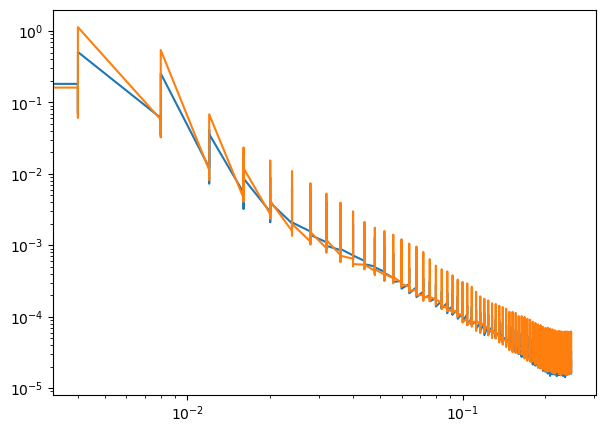

In [36]:
fig, ax = plt.subplots(figsize=(7, 5))

for swath_name in ds_mean.swath.values:
    da = ds_mean["mean_psd"].mean('passes').sel(swath=swath_name)
    ax.loglog(da.wavenumber, da, label=f"{swath_name} swath "
              f"(n={int(ds_mean['n_segments_used'].sum('passes').sel(swath=swath_name))})")

# reference power-law slopes for visual comparison (anchored at the
# lowest-wavenumber point of the first swath's spectrum)
k_ref = ds_mean.wavenumber.values[1:]
psd_ref = ds_mean["mean_psd"].isel(swath=0).values[1]
k0 = ds_mean.wavenumber.values[1]
for exponent, style in [(-2, "--"), (-11/3, ":")]:
    ax.loglog(k_ref, psd_ref * (k_ref / k0) ** exponent, style, color="gray",
              label=f"$k^{{{exponent:.0f}}}$".replace("-4", "-11/3"))

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m$^2$ / (cycles/km)]")
ax.set_title("Pass-mean along-track SSHA wavenumber spectrum")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

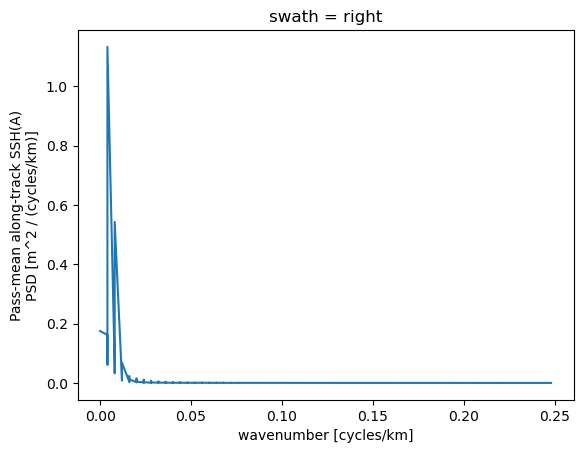

In [38]:
ds_mean["mean_psd"].mean('passes').sel(swath=swath_name).plot()

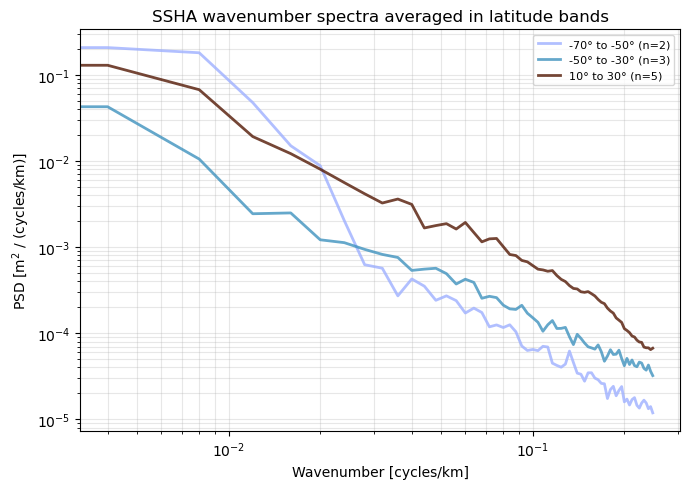

In [41]:
LAT_BIN_EDGES = np.arange(-70, 71, 20)  # adjust to the pass's latitude range
#LAT_BIN_EDGES = [-70,-40,-10,0,10,40,71]
s='1'
fig, ax = plt.subplots(figsize=(7, 5))
cmax = max(np.abs(all_datasets_seg[s]["lat_mean"].min()),np.abs(all_datasets_seg[s]["lat_mean"].max()))
norm = plt.Normalize(vmin=float(-cmax),
                      vmax=float(cmax))
cmap = plt.get_cmap("berlin")

binned = all_datasets_seg[s].groupby_bins("lat_mean", LAT_BIN_EDGES)

for lat_bin, group in binned:
    if group.sizes["segment"] == 0:
        continue
    mean_psd = group["psd"].mean(dim="segment")
    bin_center = 0.5 * (lat_bin.left + lat_bin.right)
    #ax.loglog(group.wavenumber, mean_psd,
    #          label=f"{lat_bin.left:.0f}° to {lat_bin.right:.0f}° "
    #                f"(n={group.sizes['segment']})")
    ax.loglog(group.wavenumber, mean_psd,
                  color=cmap(norm(bin_center)), lw=2., alpha=.8,
                  zorder=2,
                  label=f"{lat_bin.left:.0f}° to {lat_bin.right:.0f}° (n={group.sizes['segment']})")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m$^2$ / (cycles/km)]")
ax.set_title("SSHA wavenumber spectra averaged in latitude bands")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

In [49]:
_ds = xr.concat([all_datasets_seg[s].where((all_datasets_seg[s].lat_mean<55)&(all_datasets_seg[s].lat_mean>25),drop=True
                                ) for s in all_datasets_seg.keys() if all_datasets_seg[s] is not None],dim='passes')


/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_14922/3243127934.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'wavenumber' ('wavenumber',) The recommendation is to set join explicitly for this case.
  _ds = xr.concat([all_datasets_seg[s].where((all_datasets_seg[s].lat_mean<55)&(all_datasets_seg[s].lat_mean>25),drop=True
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_14922/3243127934.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'segment' ('segment',) The recommendation is to se

In [52]:
_ds.sel(passes=3).psd

<xarray.DataArray 'psd' (segment: 94, wavenumber: 931)> Size: 700kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(94, 931))
Coordinates:
  * segment     (segment) int64 752B 0 1 2 3 4 5 6 7 ... 86 87 88 89 90 91 92 93
  * wavenumber  (wavenumber) float64 7kB 0.0 0.003998 0.003998 ... 0.2479 0.2479
Attributes:
    long_name:  Along-track SSH(A) power spectral density
    units:      m^2 / (cycles/km)

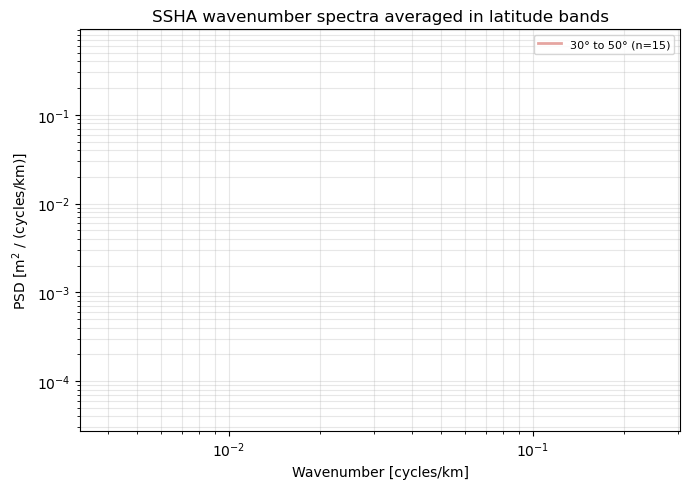

In [54]:
LAT_BIN_EDGES = np.arange(-70, 71, 20)  # adjust to the pass's latitude range
#LAT_BIN_EDGES = [-70,-40,-10,0,10,40,71]
s=0
fig, ax = plt.subplots(figsize=(7, 5))
cmax = max(np.abs(_ds.sel(passes=s)["lat_mean"].min()),np.abs(_ds.sel(passes=s)["lat_mean"].max()))
norm = plt.Normalize(vmin=float(-cmax),
                      vmax=float(cmax))
cmap = plt.get_cmap("berlin")

binned = _ds.sel(passes=s).groupby_bins("lat_mean", LAT_BIN_EDGES)

for lat_bin, group in binned:
    if group.sizes["segment"] == 0:
        continue
    mean_psd = group["psd"].mean(dim="segment")
    bin_center = 0.5 * (lat_bin.left + lat_bin.right)
    #ax.loglog(group.wavenumber, mean_psd,
    #          label=f"{lat_bin.left:.0f}° to {lat_bin.right:.0f}° "
    #                f"(n={group.sizes['segment']})")
    ax.loglog(group.wavenumber, mean_psd,
                  color=cmap(norm(bin_center)), lw=2., alpha=.8,
                  zorder=2,
                  label=f"{lat_bin.left:.0f}° to {lat_bin.right:.0f}° (n={group.sizes['segment']})")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m$^2$ / (cycles/km)]")
ax.set_title("SSHA wavenumber spectra averaged in latitude bands")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()